In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/siddharthkhatod/amex-data-r1/feature decription.csv
/kaggle/input/datasets/siddharthkhatod/amex-data-r1/r1_data.csv


In [2]:
data_df = pd.read_csv("/kaggle/input/datasets/siddharthkhatod/amex-data-r1/r1_data.csv")
feature_description = pd.read_csv("/kaggle/input/datasets/siddharthkhatod/amex-data-r1/feature decription.csv")

In [3]:
print(feature_description)

   Feature Name                   Feature Description
0            id                                    id
1            f1   Average Revolve Balance in last 12m
2            f2        Cancellation Calls in last 12m
3            f3  Cancellation Calls due to Collection
4            f4                Rewards Points Balance
5            f5               Total Spend in last 12m
6            f6                 Airlines Spend in 12m
7            f7                    Other Spend in 12m
8            f8            Entertainment Spend in 12m
9            f9                  Lodging Spend in 12m
10          f10                   Dining Spend in 12m
11          f11             Average Risk Score in 12m
12          f12               Login Counts to website
13          f13                   Lounge Access Count
14          f14              Credits used in airlines
15          f15                    Cab benefits usage
16          f16      Entertainment Credit Used Amount
17          f17             

In [4]:
data_df.describe()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23
count,500000.000000,500000.000000,500000.000000,500000.000000,242772.000000,493660.000000,384302.000000,384302.000000,384302.000000,384302.000000,...,486284.000000,486284.000000,486284.000000,207746.000000,190556.000000,499978.000000,499899.000000,242772.000000,405346.000000,61035.000000
mean,249999.500000,2467.312088,0.173948,0.108608,126607.131109,3464.813312,10032.050115,30821.546800,1522.992929,1651.736560,...,43.062608,3.992842,53.406679,24164.757131,21976.069885,1.800955,1.192771,62730.261250,4.575804,1.309904
std,144337.711634,4801.261745,0.379065,0.311147,183366.588497,3710.776424,13981.489112,39491.042972,2521.700018,2869.234123,...,71.945451,3.884681,17.841910,17461.891993,15343.872912,0.965363,0.394475,98682.348271,4.169967,0.599658
min,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,-274.646000,0.000000,0.000000,...,0.000000,0.000000,8.876771,1000.000000,1000.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,124999.750000,0.000000,0.000000,0.000000,8097.067500,668.571423,636.826300,3337.599825,0.000000,0.000000,...,0.000000,0.000000,47.816441,9800.000000,9310.000000,1.000000,1.000000,0.000000,1.000000,1.000000
50%,249999.500000,0.000000,0.000000,0.000000,50705.190000,2165.850798,4022.766000,14396.270950,303.993300,264.746000,...,0.000000,3.000000,63.115330,21728.000000,19998.000000,2.000000,1.000000,11186.360000,3.000000,1.000000
75%,374999.250000,2436.194862,0.000000,0.000000,150490.920000,4911.806492,12870.158300,41278.605275,1777.084625,1809.549225,...,72.100000,7.000000,64.403398,34650.000000,33026.000000,2.000000,1.000000,84460.000000,7.000000,1.000000
max,499999.000000,17967.726330,1.000000,1.000000,697899.350000,13596.279900,52198.432000,146700.554000,9419.874000,10828.994000,...,200.000000,11.000000,64.403398,63800.000000,54800.000000,4.000000,2.000000,365166.150000,15.000000,3.000000


In [5]:
# # # Check memory usage and basic info
# # data_df.info(memory_usage='deep')

# # # Quick check for unique values to separate continuous vs categorical/binary
# # nunique_df = data_df.nunique().reset_index()
# # nunique_df.columns = ['Feature', 'Unique_Count']
# # nunique_df = nunique_df.sort_values(by='Unique_Count')
# # print(nunique_df.head(10)) # Look for features with 2 unique values (likely binary/categorical)

# # Check memory usage and basic info
# data_df.info(memory_usage='deep')

# # Combine unique counts and null percentages into a single summary
# summary_df = pd.DataFrame({
#     'Null_Percentage': (data_df.isnull().mean() * 100).round(10),
#     'Non_Null_Percentage': (data_df.notnull().mean() * 100).round(10)
# }).reset_index()
# Feature_desc = feature_description['Feature Description']
# summary_df.columns = ['Feature','Feature_desc','Null_Percentage','Non_Null_Percentage']
# summary_df = summary_df.sort_values(by='Null_Percentage')

# print("\n--- Feature Summary ---")
# print(summary_df) # Look for features with 2 unique values and check their nulls
# Check memory usage and basic info
data_df.info(memory_usage='deep')

# Combine null percentages into a single summary
summary_df = pd.DataFrame({
    'Null_Percentage': (data_df.isnull().mean() * 100).round(10)
    # 'Non_Null_Percentage': (data_df.notnull().mean() * 100).round(10)
}).reset_index()

# 1. First, rename the 3 existing columns
summary_df.columns = ['Feature', 'Null_Percentage']

# 2. Next, add the Feature Description column (using .values to avoid index mismatches)
summary_df['Feature_desc'] = feature_description['Feature Description'].values

# 3. Rearrange the columns so the description is next to the feature name
summary_df = summary_df[['Feature', 'Feature_desc', 'Null_Percentage']]

# Sort and print
# summary_df = summary_df.sort_values(by='N')

print("\n--- Feature Summary ---")
with pd.option_context('display.precision', 10):
    print(summary_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 24 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      500000 non-null  int64  
 1   f1      500000 non-null  float64
 2   f2      500000 non-null  int64  
 3   f3      500000 non-null  int64  
 4   f4      242772 non-null  float64
 5   f5      493660 non-null  float64
 6   f6      384302 non-null  float64
 7   f7      384302 non-null  float64
 8   f8      384302 non-null  float64
 9   f9      384302 non-null  float64
 10  f10     384302 non-null  float64
 11  f11     497490 non-null  float64
 12  f12     474995 non-null  float64
 13  f13     486284 non-null  float64
 14  f14     486284 non-null  float64
 15  f15     486284 non-null  float64
 16  f16     486284 non-null  float64
 17  f17     207746 non-null  float64
 18  f18     190556 non-null  float64
 19  f19     499978 non-null  float64
 20  f20     499899 non-null  float64
 21  f21     24

In [6]:
import pandas as pd

cols_to_check = ['f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f12','f13', 
                 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 
                 'f21', 'f22', 'f23']

# FIX: Separate the integer assignment from the list initialization
total_rows = len(data_df)
zero_check_results = [] 

for col in cols_to_check:
    null_count = data_df[col].isnull().sum()
    zero_count = (data_df[col] == 0).sum()
    
    # Calculate percentages
    null_pct = (null_count / total_rows) * 100
    zero_pct = (zero_count / total_rows) * 100
    
    zero_check_results.append({
        'Feature': col,
        'Null Count': null_count,
        'Null %': f"{null_pct:.2f}%",
        'Literal Zero Count': zero_count,
        'Literal Zero %': f"{zero_pct:.2f}%"
    })

# Convert to DataFrame and display
zero_check_df = pd.DataFrame(zero_check_results)
print("--- Null vs Literal Zero Analysis ---")
# print(zero_check_df[['Literal Zero Count', 'Null Count']])
print(zero_check_df[['Feature', 'Literal Zero Count', 'Null Count']])

--- Null vs Literal Zero Analysis ---
   Feature  Literal Zero Count  Null Count
0       f4                   0      257228
1       f5               32329        6340
2       f6               56143      115698
3       f7                 631      115698
4       f8              120073      115698
5       f9              140376      115698
6      f10               36757      115698
7      f12                 736       25005
8      f13              355020       13716
9      f14              326158       13716
10     f15              158946       13716
11     f16                   0       13716
12     f17                   0      292254
13     f18                   0      309444
14     f19                   0          22
15     f20                   0         101
16     f21              103992      257228
17     f22               51966       94654
18     f23                   0      438965


In [7]:
# 1. Check Spend Categories (f5 through f10)
spend_sub_cols = ['f6', 'f7', 'f8', 'f9', 'f10']
all_sub_spend_null = data_df[spend_sub_cols].isnull().all(axis=1).sum()
any_sub_spend_null = data_df[spend_sub_cols].isnull().any(axis=1).sum()

print(f"--- Spend Categories (f5-f10) ---")
print(f"Sub-categories (f6-f10) ALL null together: {all_sub_spend_null}")
print(f"Sub-categories (f6-f10) ANY null: {any_sub_spend_null}")

# Check intersection with f5
f5_and_subs_null = data_df[spend_sub_cols + ['f5']].isnull().all(axis=1).sum()
print(f"Total Spend (f5) AND Sub-categories ALL null: {f5_and_subs_null}")

# 2. Check intersection with Risk Score (f11)
# How many missing risk scores exist specifically where the spend categories are missing?
risk_and_spend_null = data_df[data_df[spend_sub_cols].isnull().all(axis=1)]['f11'].isnull().sum()
print(f"Risk Score (f11) missing when sub-categories are missing: {risk_and_spend_null}")

# 3. Check Premium Benefits (f13 through f16)
benefit_cols = ['f13', 'f14', 'f15', 'f16']
all_benefits_null = data_df[benefit_cols].isnull().all(axis=1).sum()
any_benefits_null = data_df[benefit_cols].isnull().any(axis=1).sum()

print(f"\n--- Premium Benefits (f13-f16) ---")
print(f"Benefits ALL null together: {all_benefits_null}")
print(f"Benefits ANY null: {any_benefits_null}")

--- Spend Categories (f5-f10) ---
Sub-categories (f6-f10) ALL null together: 115698
Sub-categories (f6-f10) ANY null: 115698
Total Spend (f5) AND Sub-categories ALL null: 2202
Risk Score (f11) missing when sub-categories are missing: 896

--- Premium Benefits (f13-f16) ---
Benefits ALL null together: 13716
Benefits ANY null: 13716


In [8]:
# 1. Define the structural blocks
spend_sub_cols = ['f6', 'f7', 'f8', 'f9', 'f10']
benefit_cols = ['f13', 'f14', 'f15', 'f16']

# 2. Isolate the two cohorts
cohort_1 = data_df[data_df[spend_sub_cols].isnull().all(axis=1)]
cohort_2 = data_df[data_df[benefit_cols].isnull().all(axis=1)]

# 3. Calculate metrics
print("--- Cohort 1: Missing Spend Categories (f6-f10) ---")
print(f"Total customers in cohort: {len(cohort_1)}")
print(f"Average f17 (Total Lend Line): {cohort_1['f17'].mean():.2f}")
print(f"Average f18 (Consumer Lend Line): {cohort_1['f18'].mean():.2f}")
print(f"f17 Null Rate (Charge Card %): {(cohort_1['f17'].isnull().mean() * 100):.2f}%")

print("\n--- Cohort 2: Missing Premium Benefits (f13-f16) ---")
print(f"Total customers in cohort: {len(cohort_2)}")
print(f"Average f17 (Total Lend Line): {cohort_2['f17'].mean():.2f}")
print(f"Average f18 (Consumer Lend Line): {cohort_2['f18'].mean():.2f}")
print(f"f17 Null Rate (Charge Card %): {(cohort_2['f17'].isnull().mean() * 100):.2f}%")

print("\n--- Global Baseline (For Comparison) ---")
print(f"Global Average f17: {data_df['f17'].mean():.2f}")
print(f"Global Average f18: {data_df['f18'].mean():.2f}")

--- Cohort 1: Missing Spend Categories (f6-f10) ---
Total customers in cohort: 115698
Average f17 (Total Lend Line): 16429.07
Average f18 (Consumer Lend Line): 14535.92
f17 Null Rate (Charge Card %): 66.61%

--- Cohort 2: Missing Premium Benefits (f13-f16) ---
Total customers in cohort: 13716
Average f17 (Total Lend Line): 20533.48
Average f18 (Consumer Lend Line): 18383.43
f17 Null Rate (Charge Card %): 53.74%

--- Global Baseline (For Comparison) ---
Global Average f17: 24164.76
Global Average f18: 21976.07


In [9]:
# Isolate the cohort where Total Spend (f5) is missing
cohort_f5_null = data_df[data_df['f5'].isnull()]

# Calculate metrics
print("--- Cohort 3: Missing Total Spend (f5) ---")
print(f"Total customers in cohort: {len(cohort_f5_null)}")
print(f"Average f17 (Total Lend Line): {cohort_f5_null['f17'].mean():.2f}")
print(f"Average f18 (Consumer Lend Line): {cohort_f5_null['f18'].mean():.2f}")
print(f"f17 Null Rate (Charge Card %): {(cohort_f5_null['f17'].isnull().mean() * 100):.2f}%")

print("\n--- Global Baseline (For Comparison) ---")
print(f"Global Average f17: {data_df['f17'].mean():.2f}")
print(f"Global Average f18: {data_df['f18'].mean():.2f}")

--- Cohort 3: Missing Total Spend (f5) ---
Total customers in cohort: 6340
Average f17 (Total Lend Line): 22520.37
Average f18 (Consumer Lend Line): 21357.74
f17 Null Rate (Charge Card %): 85.22%

--- Global Baseline (For Comparison) ---
Global Average f17: 24164.76
Global Average f18: 21976.07


In [10]:
import pandas as pd
import numpy as np

# 1. Isolate the spend columns and safely fill nulls with 0 for calculation
spend_cols = ['f5', 'f6', 'f7', 'f8', 'f9', 'f10']
temp_df = data_df[spend_cols].fillna(0).copy()

# 2. Calculate the sum of the sub-categories
temp_df['sub_spend_sum'] = temp_df['f6'] + temp_df['f7'] + temp_df['f8'] + temp_df['f9'] + temp_df['f10']

# 3. Calculate what percentage of Total Spend (f5) is explained by the sub-categories
# We use np.where to prevent Division by Zero for inactive users (where f5 = 0)
temp_df['pct_of_f5'] = np.where(temp_df['f5'] > 0, 
                                (temp_df['sub_spend_sum'] / temp_df['f5']) * 100, 
                                0)

# 4. Group into 20% bins (adding a >100% bin just in case there are data anomalies)
bins = [-1, 20, 40, 60, 80, 100, np.inf]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100% (Anomaly)']
temp_df['spend_group'] = pd.cut(temp_df['pct_of_f5'], bins=bins, labels=labels)

# 5. Count customers and calculate the portfolio percentage
group_counts = temp_df['spend_group'].value_counts().sort_index().reset_index()
group_counts.columns = ['Spend Percentage Group', 'Customer Count']
group_counts['% of Total Portfolio'] = (group_counts['Customer Count'] / len(temp_df)) * 100

# Format for clean text output
group_counts['% of Total Portfolio'] = group_counts['% of Total Portfolio'].apply(lambda x: f"{x:.2f}%")

print("--- Sub-Category Spend vs. Total Spend (f5) Analysis ---")
print(group_counts.to_string(index=False))

--- Sub-Category Spend vs. Total Spend (f5) Analysis ---
Spend Percentage Group  Customer Count % of Total Portfolio
                 0-20%          159622               31.92%
                20-40%            9272                1.85%
                40-60%            7679                1.54%
                60-80%            7035                1.41%
               80-100%            6383                1.28%
       >100% (Anomaly)          309705               61.94%


In [11]:
import statsmodels.api as sm

# 1. Isolate the clean data for the regression
# We only want rows where f5 and all sub-categories exist and are strictly > 0
reg_cols = ['f5', 'f6', 'f7', 'f8', 'f9', 'f10']
reg_df = data_df[reg_cols].dropna().copy()
reg_df = reg_df[(reg_df > 0).all(axis=1)]

# 2. Define X (Sub-categories) and y (Total Spend)
# We do NOT add a constant (intercept) because 0 sub-spend = 0 total spend
X = reg_df[['f6', 'f7', 'f8', 'f9', 'f10']]
y = reg_df['f5']

# 3. Fit the Ordinary Least Squares (OLS) model
print("Fitting OLS Regression to Reverse-Engineer Scaling Factors...")
model = sm.OLS(y, X).fit()

# 4. Print the forensic results
print(model.summary())

Fitting OLS Regression to Reverse-Engineer Scaling Factors...
                                 OLS Regression Results                                
Dep. Variable:                     f5   R-squared (uncentered):                   0.396
Model:                            OLS   Adj. R-squared (uncentered):              0.396
Method:                 Least Squares   F-statistic:                          2.313e+04
Date:                Wed, 01 Jul 2026   Prob (F-statistic):                        0.00
Time:                        19:04:15   Log-Likelihood:                     -1.7259e+06
No. Observations:              176597   AIC:                                  3.452e+06
Df Residuals:                  176592   BIC:                                  3.452e+06
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|    

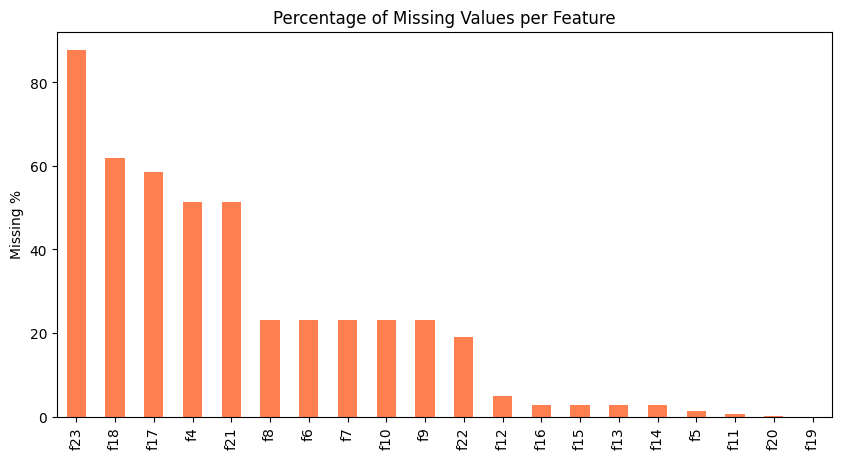

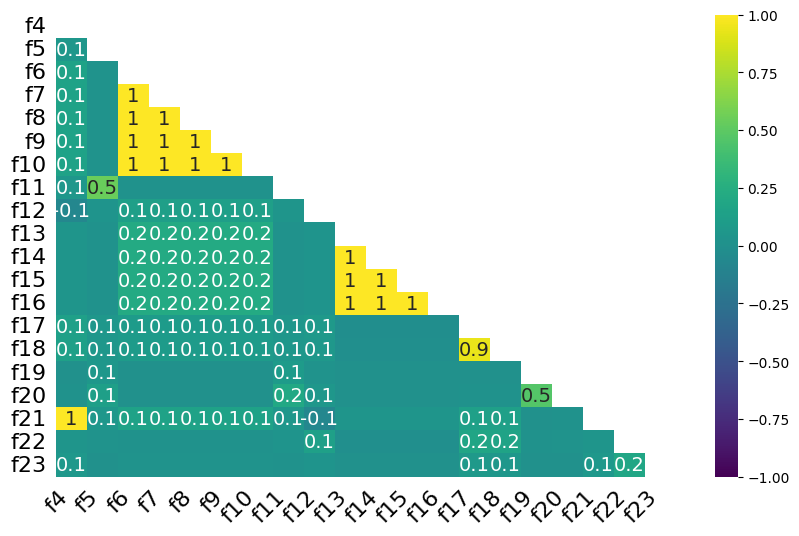

In [12]:
import missingno as msno
import matplotlib.pyplot as plt

# Plot the percentage of missing values per column
missing_pct = (data_df.isnull().sum() / len(data_df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_pct.plot(kind='bar', color='coral')
plt.title('Percentage of Missing Values per Feature')
plt.ylabel('Missing %')
plt.show()

# Plot missingness correlation (Do missing values in one column predict missing values in another?)
msno.heatmap(data_df, figsize=(10, 6), cmap='viridis')
plt.show()

Highly skewed features:
 f11    2.764671
f1     2.229196
f9     2.127089
f8     2.025816
f4     1.971216
f21    1.884067
f6     1.825405
f7     1.692012
f10    1.614218
f12    1.445973
f5     1.371610
f14    1.341533
f22    1.055595
f16   -1.440790
dtype: float64


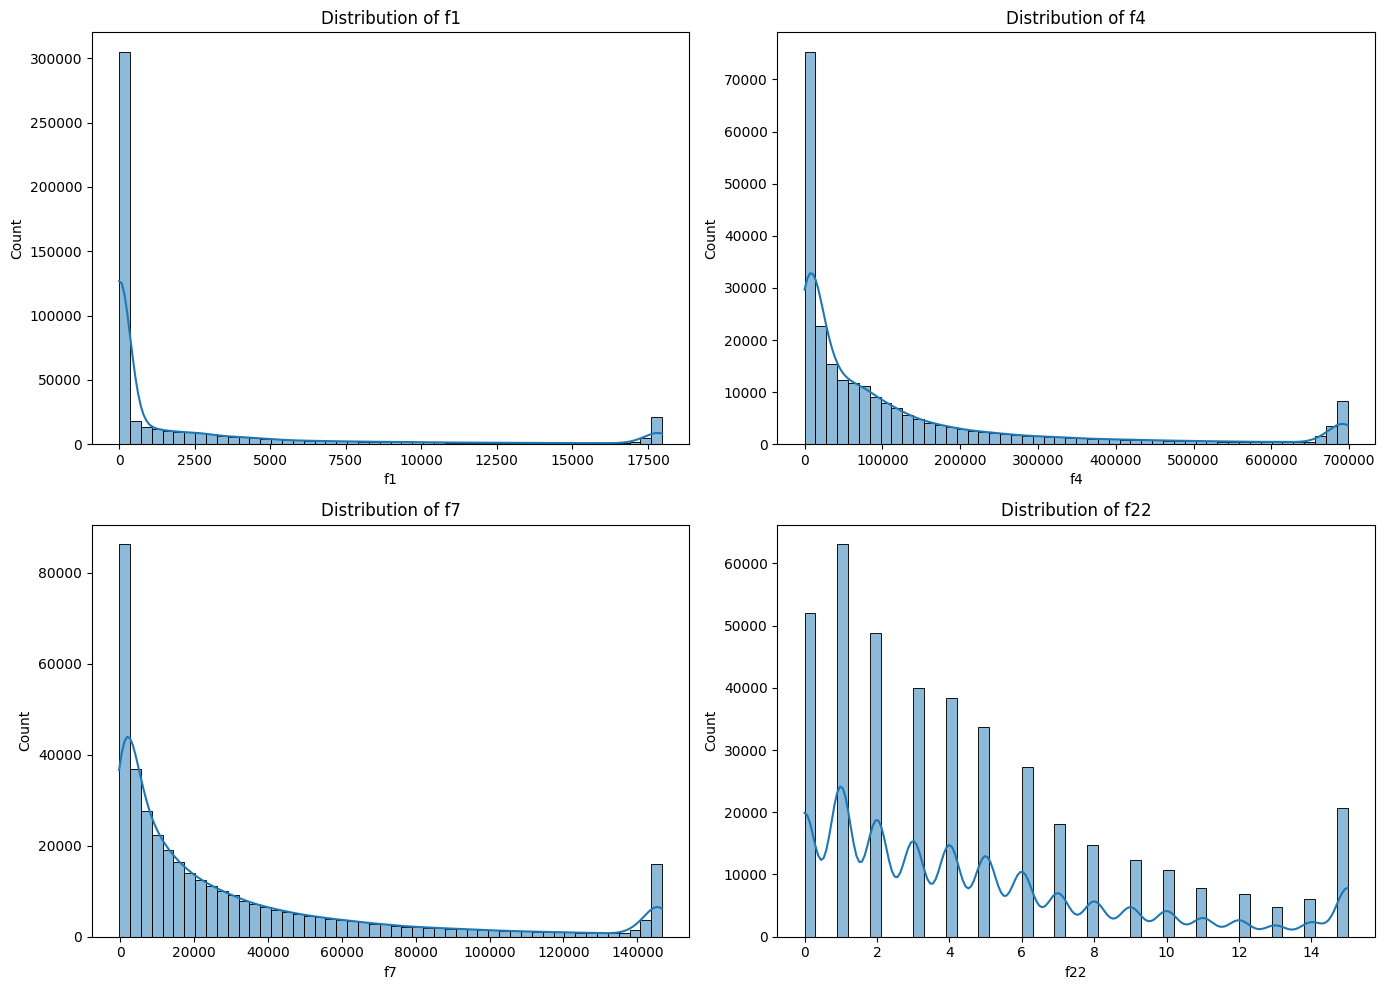

In [13]:
import seaborn as sns

# Identify numerical columns (dropping ID)
num_cols = [c for c in data_df.columns if c != 'id' and data_df[c].nunique() > 10]

# Calculate skewness to identify features that might need log-transforms later
skewness = data_df[num_cols].skew().sort_values(ascending=False)
print("Highly skewed features:\n", skewness[abs(skewness) > 1])

# Plot a few of the most continuous/variable features
features_to_plot = ['f1', 'f4', 'f7', 'f22'] # You can change these based on what looks interesting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features_to_plot):
    row, col = idx // 2, idx % 2
    sns.histplot(data_df[feature], bins=50, kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()

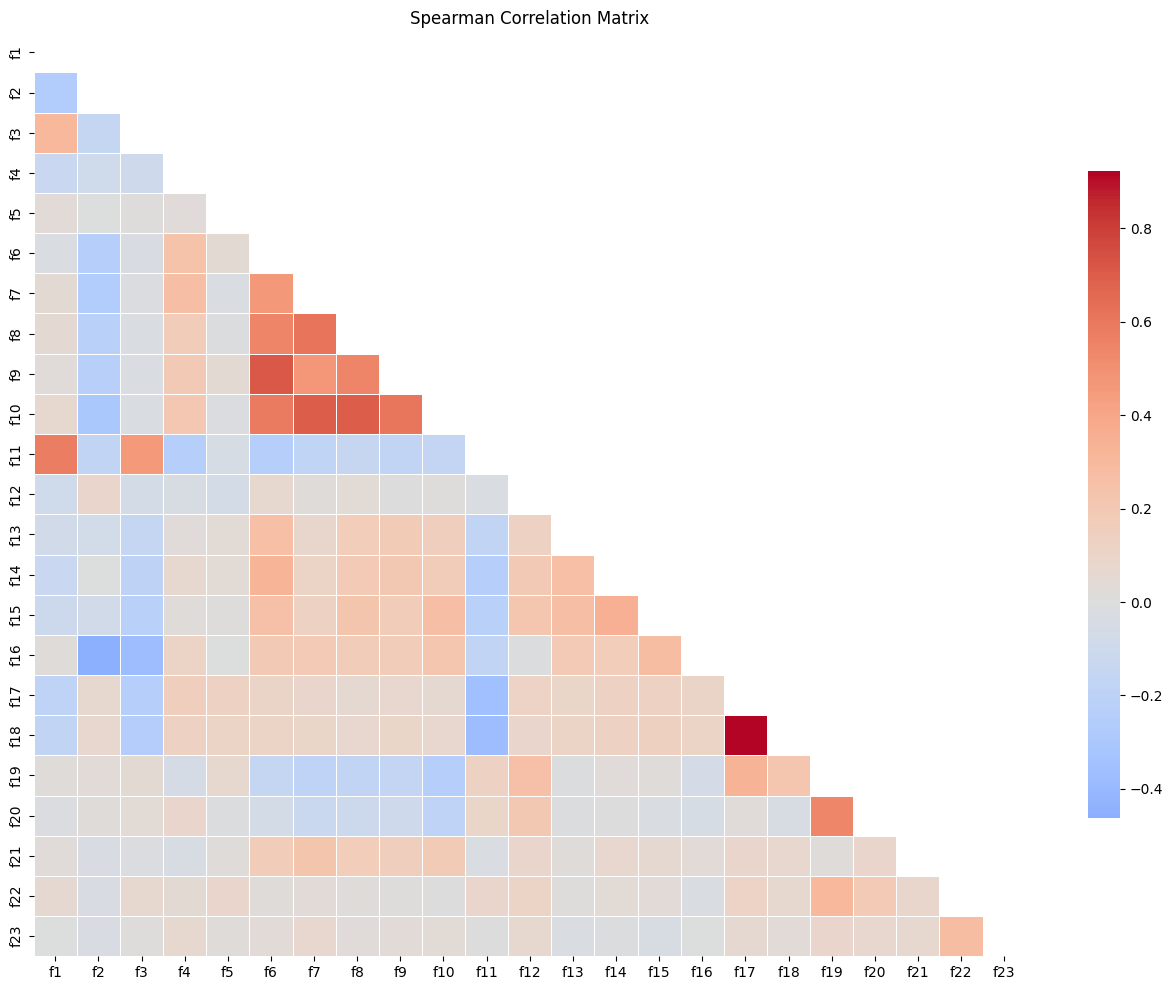

In [14]:
import numpy as np

plt.figure(figsize=(16, 12))
# Compute correlation matrix (Spearman is often better for tabular data with outliers)
corr = data_df.drop(columns=['id']).corr(method='spearman')

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, 
            annot=False, linewidths=.5, cbar_kws={"shrink": .7})
plt.title('Spearman Correlation Matrix')
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set minimalist, startup pitch-deck aesthetic
sns.set_style("white")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'

# Define strict corporate palette
slate_grey = '#708090'
corp_blue = '#1f77b4'
colors = [slate_grey, corp_blue]

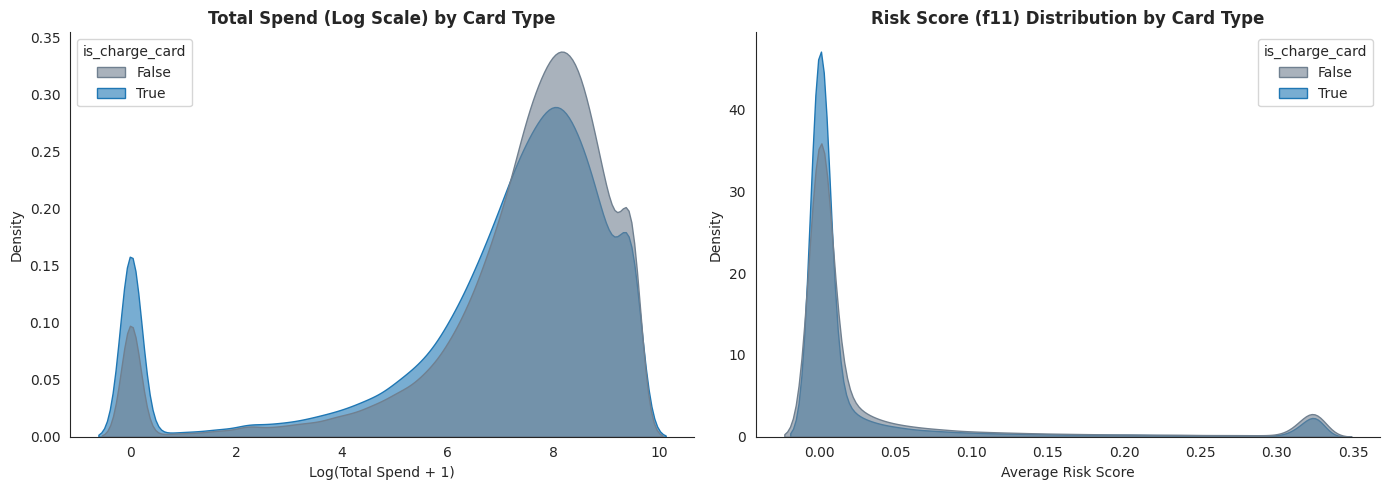

In [16]:
# Create the structural binary flag
data_df['is_charge_card'] = data_df['f17'].isnull()

# Prepare data (log transforming spend for visual clarity due to skewness)
plot_df = data_df[['f5', 'f11', 'is_charge_card']].dropna().copy()
plot_df['f5_log'] = np.log1p(plot_df['f5'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Total Spend
sns.kdeplot(data=plot_df, x='f5_log', hue='is_charge_card', fill=True, 
            palette=colors, ax=axes[0], common_norm=False, alpha=0.6)
axes[0].set_title("Total Spend (Log Scale) by Card Type", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Log(Total Spend + 1)")
axes[0].set_ylabel("Density")

# Plot Risk Score
sns.kdeplot(data=plot_df, x='f11', hue='is_charge_card', fill=True, 
            palette=colors, ax=axes[1], common_norm=False, alpha=0.6)
axes[1].set_title("Risk Score (f11) Distribution by Card Type", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Average Risk Score")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

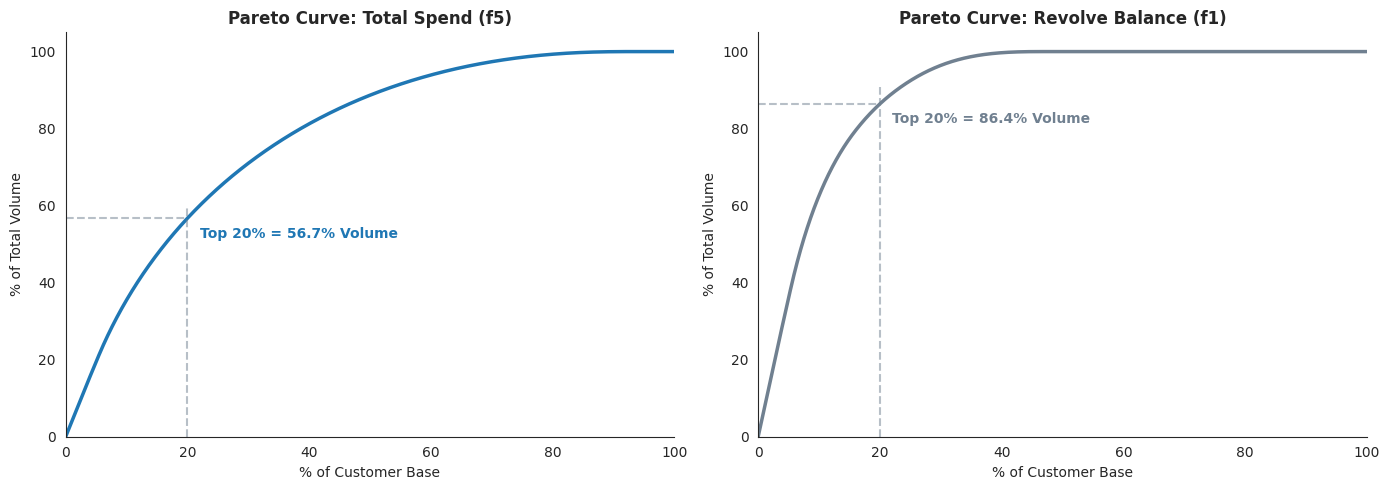

In [17]:
def plot_pareto(df, feature, title, ax, color):
    # Sort descending and calculate cumulative sum
    sorted_data = df[feature].dropna().sort_values(ascending=False)
    cumulative_sum = sorted_data.cumsum()
    cumulative_percentage = (cumulative_sum / cumulative_sum.max()) * 100
    
    # X-axis: percentage of customer base
    customer_percentage = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
    
    ax.plot(customer_percentage, cumulative_percentage, color=color, linewidth=2.5)
    
    # Add reference lines for the Top 20%
    y_at_20 = cumulative_percentage.iloc[int(len(sorted_data) * 0.2)]
    ax.axvline(20, color=slate_grey, linestyle='--', alpha=0.5, ymax=y_at_20/100) 
    ax.axhline(y_at_20, color=slate_grey, linestyle='--', alpha=0.5, xmax=0.2)
    
    # Annotate the 20% mark
    ax.text(22, y_at_20 - 5, f'Top 20% = {y_at_20:.1f}% Volume', fontsize=10, fontweight='bold', color=color)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("% of Customer Base")
    ax.set_ylabel("% of Total Volume")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 105)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_pareto(data_df, 'f5', 'Pareto Curve: Total Spend (f5)', axes[0], corp_blue)
plot_pareto(data_df, 'f1', 'Pareto Curve: Revolve Balance (f1)', axes[1], slate_grey)

plt.tight_layout()
plt.show()

/tmp/ipykernel_16/2239954684.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=f3_cohorts, x='f3_label', y='f11', palette=colors, ax=axes[0])
/tmp/ipykernel_16/2239954684.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=f3_cohorts, x='f3_label', y='f1', palette=colors, ax=axes[1])


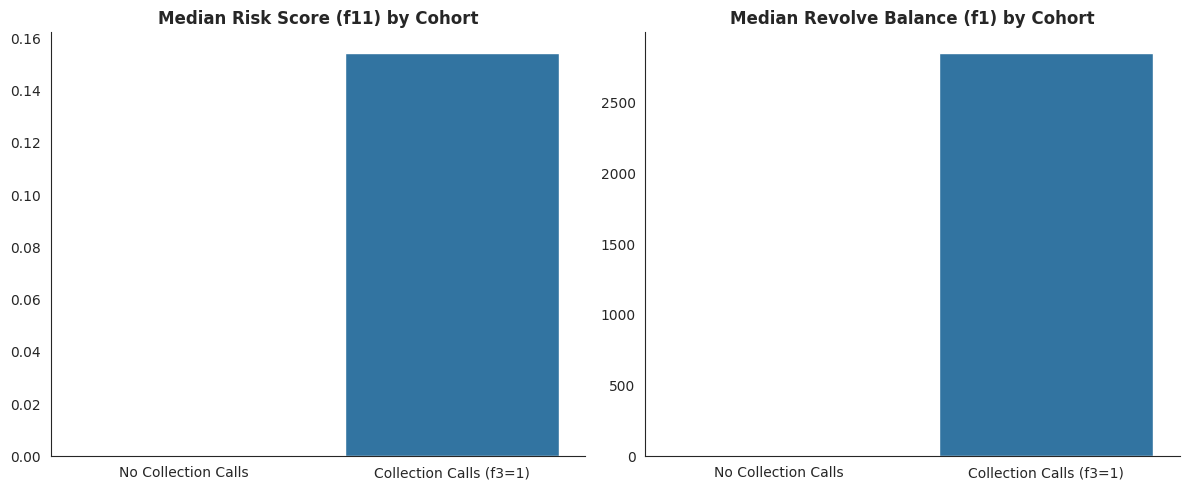

In [18]:
# Calculate medians for the collection cohorts
f3_cohorts = data_df.groupby('f3')[['f11', 'f1']].median().reset_index()
f3_cohorts['f3_label'] = f3_cohorts['f3'].map({0: 'No Collection Calls', 1: 'Collection Calls (f3=1)'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Risk Score Median
sns.barplot(data=f3_cohorts, x='f3_label', y='f11', palette=colors, ax=axes[0])
axes[0].set_title("Median Risk Score (f11) by Cohort", fontsize=12, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# Plot Revolve Balance Median
sns.barplot(data=f3_cohorts, x='f3_label', y='f1', palette=colors, ax=axes[1])
axes[1].set_title("Median Revolve Balance (f1) by Cohort", fontsize=12, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

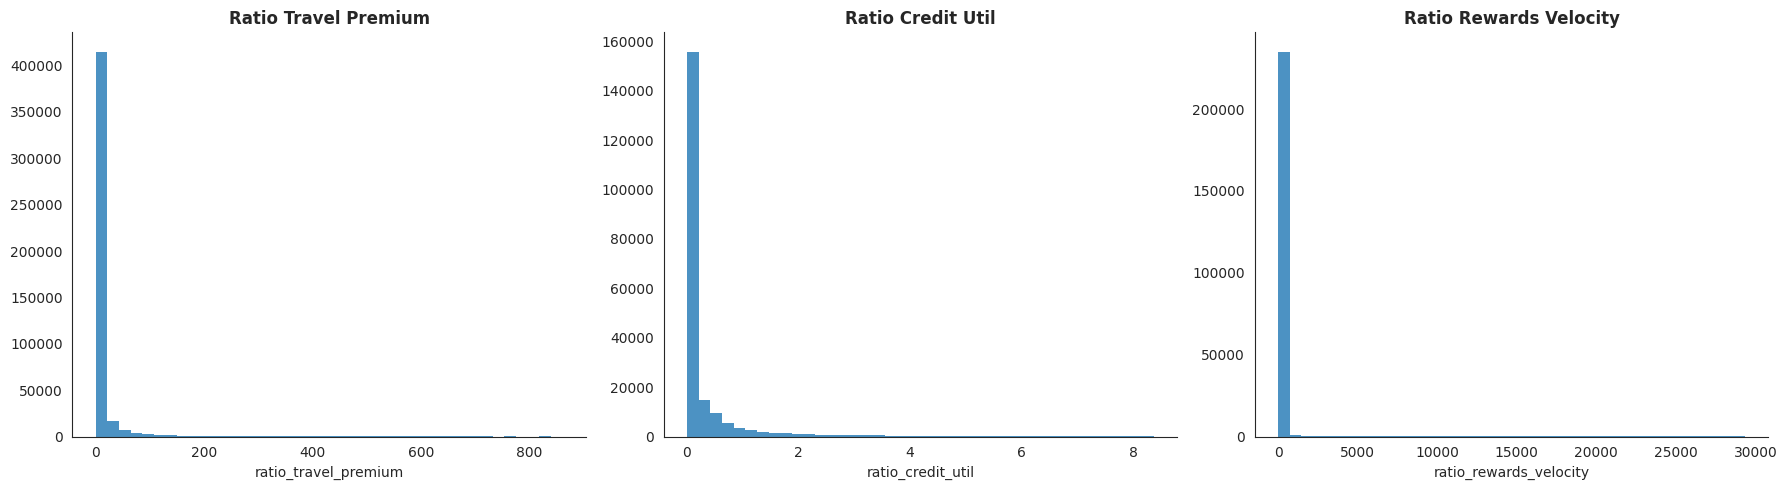

In [19]:
# Safely engineer ratios, handling division by zero and nulls
data_df['ratio_travel_premium'] = (data_df['f6'].fillna(0) + data_df['f9'].fillna(0)) / data_df['f5'].replace(0, np.nan)
data_df['ratio_credit_util'] = data_df['f1'] / data_df['f17'].replace(0, np.nan)
data_df['ratio_rewards_velocity'] = data_df['f21'] / (data_df['f4'] + 1)

ratios = ['ratio_travel_premium', 'ratio_credit_util', 'ratio_rewards_velocity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(ratios):
    # Drop NAs and Infs for plotting, and trim the top 1% outliers for visual clarity
    plot_data = data_df[col].replace([np.inf, -np.inf], np.nan).dropna()
    cap = plot_data.quantile(0.99)
    
    sns.histplot(plot_data[plot_data <= cap], bins=40, color=corp_blue, ax=axes[i], alpha=0.8, edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

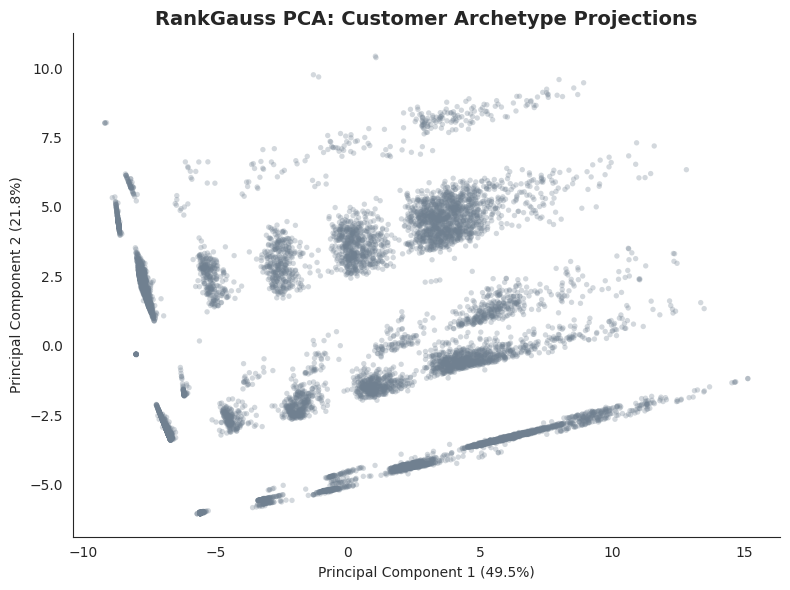

In [20]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA

# Select continuous financial columns
cont_cols = ['f1', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']

# Impute strictly for dimensionality reduction
pca_df = data_df[cont_cols].copy()
for col in cont_cols:
    if col == 'f11':
        pca_df[col] = pca_df[col].fillna(pca_df[col].median())
    else:
        pca_df[col] = pca_df[col].fillna(0)

# Apply RankGauss (QuantileTransformer) to force a normal distribution
transformer = QuantileTransformer(output_distribution='normal', random_state=42)
transformed_data = transformer.fit_transform(pca_df)

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(transformed_data)

plt.figure(figsize=(8, 6))

# Randomly sample 10k points so the plot doesn't turn into a solid, unreadable block
idx = np.random.choice(range(len(pca_results)), size=10000, replace=False)
plt.scatter(pca_results[idx, 0], pca_results[idx, 1], alpha=0.3, color=slate_grey, s=15, edgecolors='none')

plt.title('RankGauss PCA: Customer Archetype Projections', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

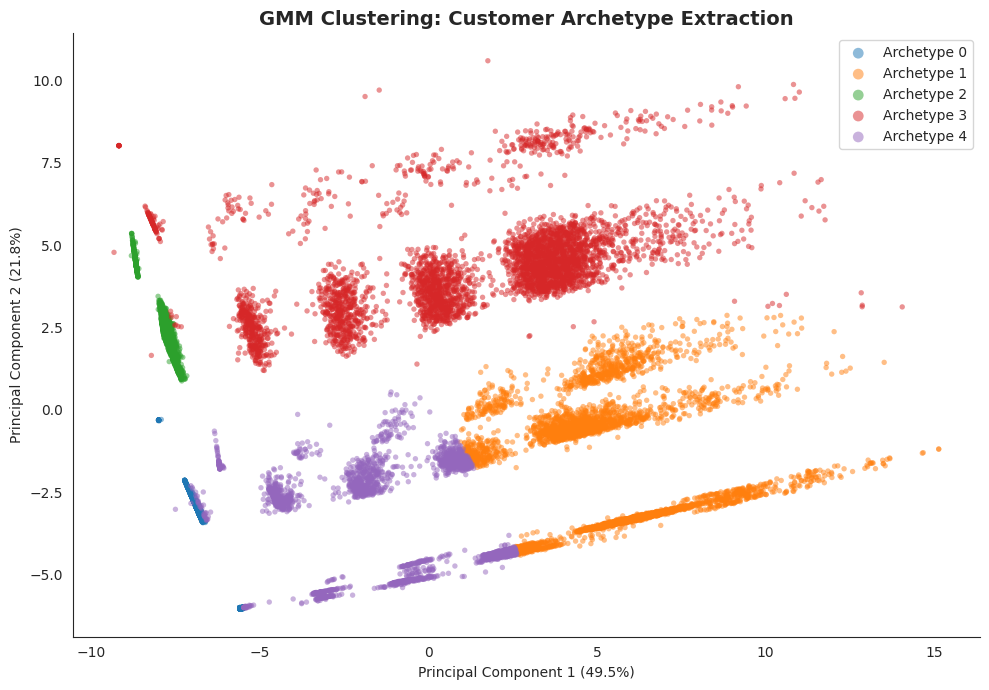


--- Cluster Archetype Profiling ---


,archetype_cluster,customer_count,median_risk_score,collection_call_rate,avg_lounge_access
0,0,55931,0.000268,0.104200,0.195688
1,1,152663,0.000000,0.000393,0.743510
2,2,69518,0.101213,0.653788,0.116720
3,3,136418,0.006122,0.018436,0.494224
4,4,85470,0.000000,0.005277,0.428944


In [21]:
from sklearn.mixture import GaussianMixture

# 1. Fit GMM to the PCA results (we'll start with 5 distinct archetypes based on the visual bands)
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
cluster_labels = gmm.fit_predict(pca_results)

# Add the cluster labels and PCA coordinates back to our tracking dataframe
data_df['archetype_cluster'] = cluster_labels
data_df['pca_1'] = pca_results[:, 0]
data_df['pca_2'] = pca_results[:, 1]

# 2. Visualize the GMM Clusters
plt.figure(figsize=(10, 7))

# Define a distinct 5-color categorical palette
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot a sample to avoid overplotting
sample_idx = np.random.choice(range(len(pca_results)), size=15000, replace=False)
for i in range(5):
    cluster_points = (cluster_labels[sample_idx] == i)
    plt.scatter(pca_results[sample_idx][cluster_points, 0], 
                pca_results[sample_idx][cluster_points, 1], 
                alpha=0.5, s=15, edgecolors='none', 
                c=cluster_colors[i], label=f'Archetype {i}')

plt.title('GMM Clustering: Customer Archetype Extraction', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 (49.5%)')
plt.ylabel(f'Principal Component 2 (21.8%)')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

# 3. Cross-Reference Clusters with the Risk Anchor (f3) and Premium Anchor (f13)
# We want to see if one specific archetype absorbs all the credit risk or premium benefits
cluster_profiling = data_df.groupby('archetype_cluster').agg(
    customer_count=('id', 'count'),
    median_risk_score=('f11', 'median'),
    collection_call_rate=('f3', 'mean'), # Percentage of customers in collections
    avg_lounge_access=('f13', 'mean')    # Proxy for premium tier
).reset_index()

print("\n--- Cluster Archetype Profiling ---")
display(cluster_profiling.style.background_gradient(cmap='Blues'))

In [22]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Create a copy for scoring
score_df = data_df.copy()

# 1. Fill NAs contextually for the math equation
score_df['f5_filled'] = score_df['f5'].fillna(0)             # Spend
score_df['f1_filled'] = score_df['f1'].fillna(0)             # Revolve Balance
score_df['f11_filled'] = score_df['f11'].fillna(score_df['f11'].median()) # Risk Score
score_df['f21_filled'] = score_df['f21'].fillna(0)           # Rewards Redeemed

# 2. MinMax Scale the continuous components so they interact proportionally
scaler = MinMaxScaler()
cols_to_scale = ['f5_filled', 'f1_filled', 'f11_filled', 'f21_filled']
score_df[cols_to_scale] = scaler.fit_transform(score_df[cols_to_scale])

# 3. Define the Hyperparameter Weights (These will be optimized via Leaderboard probing later)
W_REV = 1.0     # Weight for revenue
W_INT = 0.5     # Weight for interest (lower margin than pure spend)
W_RISK = 2.0    # Heavy penalty for credit loss
W_COST = 0.3    # Slight penalty for rewards/servicing
W_DEFAULT = 5.0 # Massive penalty for being in collections
W_CHURN = 2.0   # Penalty for cancellation calls

# 4. Compute the Components
# Revenue: Scaled Spend + Scaled Revolve Balance (only if not a charge card)
revenue = (W_REV * score_df['f5_filled']) + (W_INT * score_df['f1_filled'] * (~score_df['is_charge_card']).astype(int))

# Risk: (Scaled Risk * Scaled Revolve Balance) + Hard penalty for f3
ecl = (W_RISK * (score_df['f11_filled'] * score_df['f1_filled'])) + (W_DEFAULT * score_df['f3'])

# Costs: Rewards + Cancellation Calls
costs = (W_COST * score_df['f21_filled']) + (W_CHURN * score_df['f2'])

# 5. Compute Final Proxy Score
score_df['S_proxy'] = revenue - ecl - costs

# 6. Apply Archetype Hard-Constraints
# We know Archetype 2 is extreme risk, so we aggressively floor their score
score_df.loc[score_df['archetype_cluster'] == 2, 'S_proxy'] -= 10.0

# Rank the customers based on the continuous score
score_df['proxy_rank'] = score_df['S_proxy'].rank(ascending=False, method='min')

print("--- Top 10 Most Profitable Customers (Proxy) ---")
display(score_df.nsmallest(10, 'proxy_rank')[['id', 'f5', 'f1', 'f13', 'f11', 'S_proxy']])

print("\n--- Bottom 10 Least Profitable Customers (Proxy) ---")
display(score_df.nlargest(10, 'proxy_rank')[['id', 'f3', 'f11', 'f1', 'archetype_cluster', 'S_proxy']])

--- Top 10 Most Profitable Customers (Proxy) ---


,id,f5,f1,f13,f11,S_proxy
82764,82764,13596.2799,17967.72633,2.0,0.000000,1.500000
437948,437948,13596.2799,17967.72633,1.0,0.000000,1.500000
476224,476224,13596.2799,17967.72633,0.0,0.000000,1.500000
144838,144838,13596.2799,17967.72633,0.0,0.000042,1.499745
125059,125059,13596.2799,17967.72633,0.0,0.000126,1.499227
449389,449389,13596.2799,17967.72633,3.0,0.000175,1.498927
71358,71358,13596.2799,17967.72633,2.0,0.000204,1.498751
396961,396961,13596.2799,17967.72633,0.0,0.000267,1.498362
30341,30341,13596.2799,17967.72633,3.0,0.000278,1.498294
11595,11595,13596.2799,17967.72633,1.0,0.000428,1.497374



--- Bottom 10 Least Profitable Customers (Proxy) ---


,id,f3,f11,f1,archetype_cluster,S_proxy
61656,61656,1,0.000758,17608.37181,2,-17.276324
459353,459353,1,0.326310,17608.37181,2,-17.257000
174068,174068,1,0.088236,16891.73358,2,-17.235858
253896,253896,1,0.326310,17788.04907,2,-17.090948
438409,438409,1,0.326310,17788.04907,2,-17.088768
58846,58846,1,0.313903,17007.13657,2,-17.062386
173724,173724,1,0.326310,17249.01728,2,-17.055218
97805,97805,1,0.309995,17608.37181,2,-17.052232
196510,196510,1,0.001969,885.93715,2,-17.046567
346334,346334,1,0.319784,17249.01728,2,-17.037583


In [23]:
# ---------------------------------------------------------
# SUBMISSION 1: The Baseline Proxy Score
# ---------------------------------------------------------
# Sort by our proxy rank (1 is highest profitability)
sub1 = score_df[['id', 'proxy_rank']]
# Rename to whatever the competition expects (e.g., 'prediction' or 'score')
sub1.columns = ['id', 'prediction'] 
sub1.to_csv('submission_1_baseline_proxy.csv', index=False)

# ---------------------------------------------------------
# SUBMISSION 2: The Transactor/Revolver Delta Probe
# ---------------------------------------------------------
# Let's test if the organizer heavily weights Interchange (Spend) or NII (Interest)
# We create a modified proxy that boosts Charge Cards (Interchange dominant)
score_df['S_proxy_charge_boost'] = score_df['S_proxy'] + (score_df['is_charge_card'].astype(int) * 2.0)
score_df['probe_rank'] = score_df['S_proxy_charge_boost'].rank(ascending=False, method='min')

sub2 = score_df[['id', 'probe_rank']].sort_values('probe_rank')
sub2.columns = ['id', 'prediction']
sub2.to_csv('submission_2_charge_boost.csv', index=False)

print("Generated submission_1_baseline_proxy.csv and submission_2_charge_boost.csv")

Generated submission_1_baseline_proxy.csv and submission_2_charge_boost.csv


In [24]:
# Create a fresh copy for deep learning feature engineering
dl_df = data_df.copy()

# 1. Revolving Utilization (Fill null lend lines with a large number to avoid div/0 for charge cards)
dl_df['util_total'] = dl_df['f1'] / dl_df['f17'].replace(0, np.nan).fillna(999999)
dl_df['util_consumer'] = dl_df['f1'] / dl_df['f18'].replace(0, np.nan).fillna(999999)

# 2. Basel CCF Exposure Metric (EAD)
# EAD = f1 + 0.10 * (f18 - f1). If f18 is null, we assume EAD is just f1.
dl_df['ead_proxy'] = dl_df['f1'] + 0.10 * (dl_df['f18'].fillna(dl_df['f1']) - dl_df['f1'])

# 3. Discretionary Spend Density
# Fill spend NAs with 0
for col in ['f5', 'f6', 'f7', 'f8', 'f9', 'f10']:
    dl_df[col] = dl_df[col].fillna(0)
    
dl_df['travel_ent_density'] = (dl_df['f6'] + dl_df['f8'] + dl_df['f9'] + dl_df['f10']) / (dl_df['f5'] + 1)
dl_df['retail_density'] = dl_df['f7'] / (dl_df['f5'] + 1)

# 4. Rewards Burn Velocity & Benefit Saturation
dl_df['f4'] = dl_df['f4'].fillna(0)
dl_df['f21'] = dl_df['f21'].fillna(0)
dl_df['burn_velocity'] = dl_df['f21'] / (dl_df['f4'] + dl_df['f21'] + 1)

benefit_cols = ['f13', 'f14', 'f15', 'f16']
for col in benefit_cols:
    dl_df[col] = dl_df[col].fillna(0)
dl_df['benefit_saturation'] = (dl_df['f13'] + dl_df['f14'] + dl_df['f15'] + dl_df['f16']) / (dl_df['f5'] + 1)

# 5. Credit Distress Trajectory & Supplementary Leverage
dl_df['f11'] = dl_df['f11'].fillna(dl_df['f11'].median())
dl_df['risk_to_collection'] = dl_df['f3'] * dl_df['f11']

dl_df['f19'] = dl_df['f19'].fillna(0)
dl_df['f20'] = dl_df['f20'].fillna(0)
dl_df['spend_per_card'] = dl_df['f5'] / (dl_df['f19'] + dl_df['f20'] + 1)

print(f"Master feature matrix constructed. Shape: {dl_df.shape}")

Master feature matrix constructed. Shape: (500000, 40)


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler

# 1. Prepare the data for the Autoencoder
# Select all continuous and engineered features
features_for_ae = ['f1', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 
                   'f12', 'f13', 'f14', 'f15', 'f16', 'f21', 'f22', 'f23',
                   'util_total', 'ead_proxy', 'travel_ent_density', 
                   'burn_velocity', 'benefit_saturation', 'spend_per_card']

ae_data = dl_df[features_for_ae].fillna(0).copy()

# We must standard scale for neural network stability
scaler_ae = StandardScaler()
ae_scaled = scaler_ae.fit_transform(ae_data)

# 2. Build the Deep Autoencoder Architecture
input_dim = ae_scaled.shape[1]
latent_dim = 16

# Encoder
inputs = layers.Input(shape=(input_dim,))
e = layers.Dense(64, activation='relu')(inputs)
e = layers.BatchNormalization()(e)
e = layers.Dropout(0.2)(e)
e = layers.Dense(32, activation='relu')(e)
latent_space = layers.Dense(latent_dim, activation='linear', name='bottleneck')(e)

# Decoder
d = layers.Dense(32, activation='relu')(latent_space)
d = layers.BatchNormalization()(d)
d = layers.Dense(64, activation='relu')(d)
outputs = layers.Dense(input_dim, activation='linear')(d)

autoencoder = Model(inputs, outputs)
encoder = Model(inputs, latent_space)

autoencoder.compile(optimizer='adam', loss='mse')

# 3. Train the Autoencoder (Quick 10-epoch run)
print("Training Deep Autoencoder...")
history = autoencoder.fit(
    ae_scaled, ae_scaled,
    epochs=50,
    batch_size=2048,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

# 4. Extract Latent Embeddings
print("Extracting 16D Latent Embeddings...")
latent_embeddings = encoder.predict(ae_scaled, batch_size=2048)

# Add embeddings back to our dataframe to use in our final ranker later
for i in range(latent_dim):
    dl_df[f'ae_latent_{i}'] = latent_embeddings[:, i]

print("Successfully captured unsupervised deep representations.")

2026-07-01 19:05:11.231448: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782932711.509233      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782932711.593418      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782932712.340856      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782932712.340892      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782932712.340896      16 computation_placer.cc:177] computation placer alr

Training Deep Autoencoder...
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.5096 - val_loss: 0.2359
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2003 - val_loss: 0.1222
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1327 - val_loss: 0.0757
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1014 - val_loss: 0.0520
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0853 - val_loss: 0.0424
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0758 - val_loss: 0.0361
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0679 - val_loss: 0.0288
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0588 - val_loss: 0.0222
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0545 - val_loss: 0.0206
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0515 - val_loss: 0.0185
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0496 - val_loss: 0.0166
Epoch 12/50
196/196 

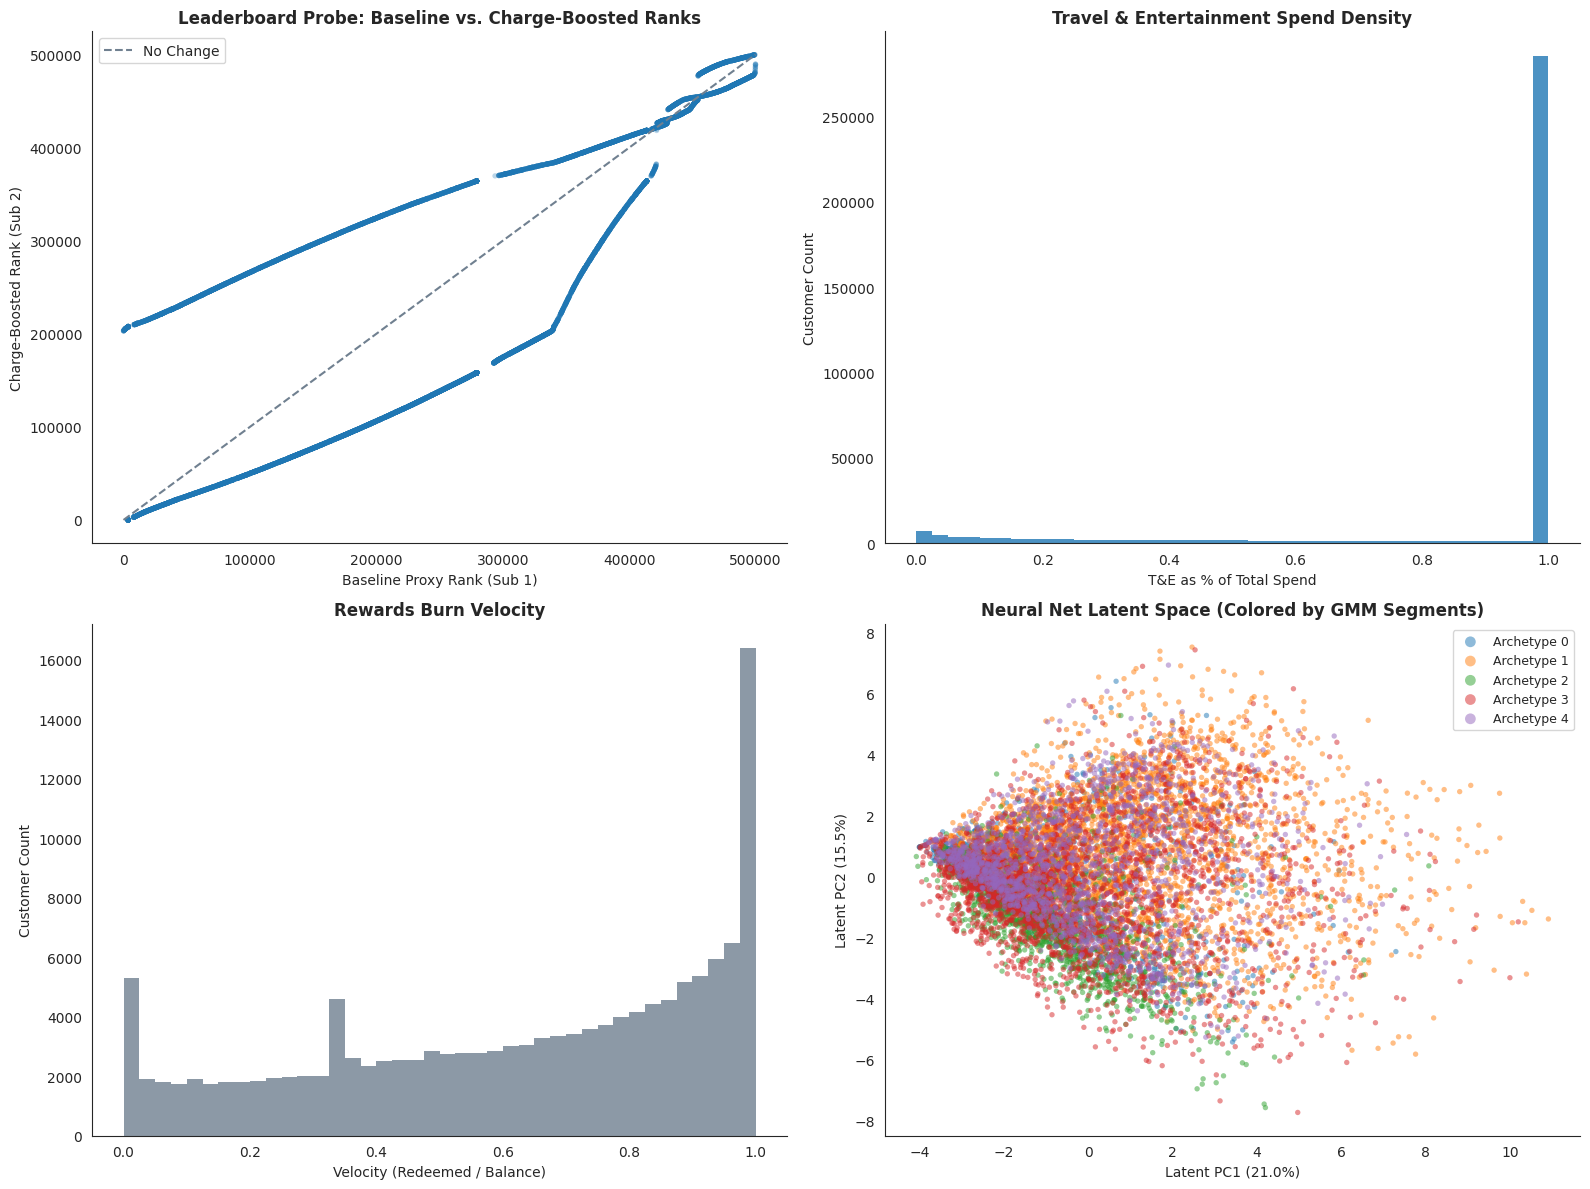

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

# Set aesthetic
sns.set_style("white")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
corp_blue = '#1f77b4'
slate_grey = '#708090'
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig = plt.figure(figsize=(16, 12))

# ---------------------------------------------------------
# Plot 1: The Leaderboard Probe (Rank Shift)
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
# Sample 10k points to avoid plotting 500k overlapping dots
sample_df = score_df.sample(10000, random_state=42)

ax1.scatter(sample_df['proxy_rank'], sample_df['probe_rank'], 
            alpha=0.3, s=15, c=corp_blue, edgecolors='none')
ax1.plot([0, 500000], [0, 500000], color=slate_grey, linestyle='--', label='No Change') # Identity line

ax1.set_title('Leaderboard Probe: Baseline vs. Charge-Boosted Ranks', fontsize=12, fontweight='bold')
ax1.set_xlabel('Baseline Proxy Rank (Sub 1)')
ax1.set_ylabel('Charge-Boosted Rank (Sub 2)')
ax1.legend()

# ---------------------------------------------------------
# Plot 2 & 3: New Domain-Engineered Features
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
# Cap at 1.0 (100% density) for clean visualization
te_density = dl_df['travel_ent_density'].clip(upper=1.0)
sns.histplot(te_density[te_density > 0], bins=40, color=corp_blue, ax=ax2, alpha=0.8, edgecolor='none')
ax2.set_title('Travel & Entertainment Spend Density', fontsize=12, fontweight='bold')
ax2.set_ylabel('Customer Count')
ax2.set_xlabel('T&E as % of Total Spend')

ax3 = plt.subplot(2, 2, 3)
burn_rate = dl_df['burn_velocity'].clip(upper=1.0)
sns.histplot(burn_rate[burn_rate > 0], bins=40, color=slate_grey, ax=ax3, alpha=0.8, edgecolor='none')
ax3.set_title('Rewards Burn Velocity', fontsize=12, fontweight='bold')
ax3.set_ylabel('Customer Count')
ax3.set_xlabel('Velocity (Redeemed / Balance)')

# ---------------------------------------------------------
# Plot 4: Autoencoder Latent Space Projection
# ---------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)
# We compress the 16 latent dimensions down to 2 just for visualization
latent_cols = [f'ae_latent_{i}' for i in range(16)]
pca_ae = PCA(n_components=2, random_state=42)
ae_2d = pca_ae.fit_transform(dl_df[latent_cols])

sample_idx = np.random.choice(range(len(ae_2d)), size=10000, replace=False)

# Color by the GMM archetype to see if the neural net learned the same rules
for i in range(5):
    cluster_points = (dl_df['archetype_cluster'].iloc[sample_idx] == i).values
    ax4.scatter(ae_2d[sample_idx][cluster_points, 0], 
                ae_2d[sample_idx][cluster_points, 1], 
                alpha=0.5, s=15, edgecolors='none', 
                c=cluster_colors[i], label=f'Archetype {i}')

ax4.set_title('Neural Net Latent Space (Colored by GMM Segments)', fontsize=12, fontweight='bold')
ax4.set_xlabel(f'Latent PC1 ({pca_ae.explained_variance_ratio_[0]*100:.1f}%)')
ax4.set_ylabel(f'Latent PC2 ({pca_ae.explained_variance_ratio_[1]*100:.1f}%)')
ax4.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
import xgboost as xgb
import pandas as pd
import numpy as np

# 1. Prepare the Weak Supervision Training Data
# We attach our continuous proxy score to act as the pseudo-label
train_df = dl_df.copy()
train_df['target_proxy_score'] = score_df['S_proxy']

# Drop non-predictive columns and the GMM cluster (we want the model to learn the rules itself)
features = [c for c in train_df.columns if c not in ['id', 'target_proxy_score', 'archetype_cluster']]

# 2. Construct Artificial Query Groups for Pairwise Ranking
# XGBRanker requires data to be grouped by "queries". 
# We will create groups of 5,000 customers to pit against each other.
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle
train_df['query_group'] = (train_df.index // 5000)

# Sort strictly by group, then by target score descending (Required for XGBRanker)
train_df = train_df.sort_values(['query_group', 'target_proxy_score'], ascending=[True, False])

X = train_df[features]
y = train_df['target_proxy_score']
groups = train_df.groupby('query_group').size().to_numpy()

# 3. Initialize and Train the Pairwise Ranker
print("Initializing XGBoost Pairwise Ranker...")
ranker = xgb.XGBRanker(
    objective='rank:pairwise',
    tree_method='hist',      # Fast histogram binning for large tabular data
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=300,
    random_state=42
)

print("Training Ranker on Pseudo-Labels...")
ranker.fit(X, y, group=groups, verbose=True)

# 4. Generate Predictions on the Full Dataset
print("Scoring Full Portfolio...")
# We predict on the original sorted dl_df to maintain ID order
dl_df['xgb_rank_score'] = ranker.predict(dl_df[features])

# Rank the outputs (1 is most profitable)
dl_df['final_ml_rank'] = dl_df['xgb_rank_score'].rank(ascending=False, method='min')

# 5. Export Submission 3
sub3 = dl_df[['id', 'final_ml_rank']].copy()
sub3.columns = ['id', 'prediction']
sub3.to_csv('submission_3_xgb_pairwise.csv', index=False)

print("Successfully generated submission_3_xgb_pairwise.csv")

Initializing XGBoost Pairwise Ranker...
Training Ranker on Pseudo-Labels...
Scoring Full Portfolio...
Successfully generated submission_3_xgb_pairwise.csv
